# PREAMBLE

We will look at how to run Markov chain Monte Carlos (MCMCs) on data using **emcee**, a pure-Python implementation of a MCMC ensemble sampler (to be specific: [Goodman & Weare’s Affine Invariant Markov chain Monte Carlo Ensemble sampler](https://msp.org/camcos/2010/5-1/camcos-v5-n1-p04-p.pdf)).

When a package is missing in your environment, e.g., `emcee`, you can install it by running
```
!pip install emcee
```
in Jupyter or
```
pip install emcee
```
on a terminal window.  This requires your machine to be supplied with `pip`, and it works on Colab.

If you have multiple `pip` commands available in your terminal (`pip`, `pip3`, `pip3.10`, etc.) make sure you invoke the one that matches the interpreter you are using with Jupyter.  To check the Python version you are using, run the following lines

In [5]:
from platform import python_version
print(python_version())
!pip3 install emcee

3.12.3


/bin/bash: line 1: pip3: command not found


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import emcee

## Let's cook up some data to analyze

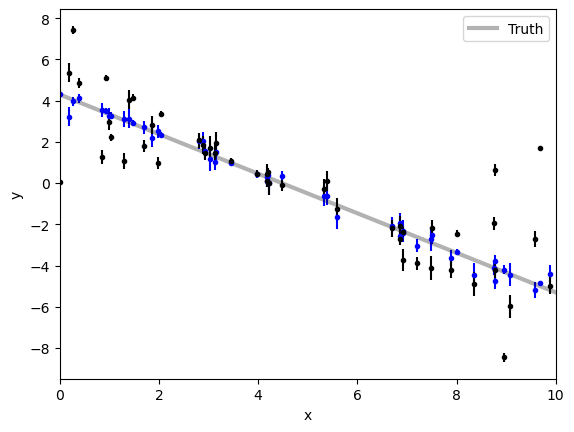

In [5]:
# Fixing the seed to make the random numbers are reproducible
np.random.seed(1)

# Specify "truth": y = mx + q
m_true = -0.9594
q_true = 4.294
true_dict = {'m': m_true, 'q': q_true}

# Generate some synthetic data from the "truth"
N = 50
x = np.sort(10 * np.random.rand(N))
y = m_true * x + q_true

# Generate the QUOTED (Gaussian) uncertainties on such data
yerr = 0.1 + 0.5 * np.random.rand(N)
# and polute the y values with these errors (randn extracts from a Gaussian with mean 0 and width 1)
y += yerr * np.random.randn(N)
plt.errorbar(x, y, yerr=yerr, fmt=".b", capsize=0)
# Specify an amplitude for Gaussian noise that the QUOTED measurement does not account for
f_true = 0.534

# Ensure that the QUOTED uncertainties understimate the ACTUAL ones
# by a constant fractional amount f_true * gaussian noise
y += np.abs(f_true * y) * np.random.randn(N)

# Plot the "truth" and the simulated data, i.e., the ACTUAL y values with their QUOTED errors
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + q_true, "k", alpha=0.3, lw=3, label="Truth")
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")
plt.legend();

## Least-squared fit with `scipy.optimize.curve_fit`

Notice the optional argument `sigma=yerr` to pass the **quoted** errorbars to the fitting algorithm.

In [6]:
def fitfunc(x, m, q):
    return m*x + q

param_labels = ['m', 'q']

fit_pars, cov_matrix = curve_fit(fitfunc, x, y, sigma=yerr)

for i in range(len(param_labels)):
    print(f"{np.abs(100*cov_matrix[i, i]**0.5/fit_pars[i]): .1f}% error on parameter {param_labels[i]}")
    print(f"{fit_pars[i]: .4f} +/-{cov_matrix[i, i]**0.5: .4f} (true value {true_dict[param_labels[i]]})\n")

 19.9% error on parameter m
-0.5222 +/- 0.1038 (true value -0.9594)

 17.4% error on parameter q
 3.1797 +/- 0.5547 (true value 4.294)



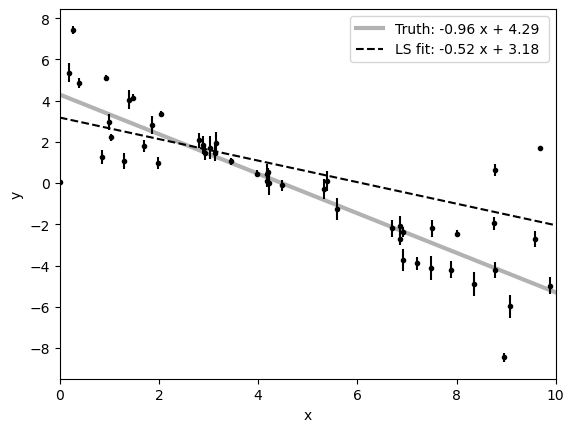

In [7]:
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + q_true, "k", alpha=0.3, lw=3, label="Truth: %.2f x + %.2f " % (m_true, q_true))
plt.plot(x0, fitfunc(x0, *fit_pars), '--k', label="LS fit: %.2f x + %.2f" % tuple(fit_pars))
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")
plt.legend();

The result is reasonable (notice how the cluster of data points affects it), but the uncertainties on the two parameters are small, because of the small error bars on most of the data points.

## Maximum likelihood estimation

**The least squares solution is the maximum likelihood result for a model where the error bars are assumed to be**:
1. correct,
1. Gaussian, and
1. independent.

But these assumptions may not hold, and they definitely do not in this case!  Additionally, there is no generalization of least squares that supports a model like the one that we know to be true. Instead, we need to write down the likelihood function and numerically optimize it.

`emcee` uses logarithms of probability densities, so we focus on the log-likelihood and write out a Gaussian with variance underestimated by some fractional amount $f$:
$$
\ln \mathcal{L}(\mathbf{d}|\boldsymbol{\theta},\mathcal{I}) = \ln p(\mathbf{y}| \{m,q,f\}, \mathbf{x}, \boldsymbol{\sigma}) = -{1\over 2}\sum_k\left[ {{(y_k - mx_k - q)^2}\over {s_k^2}} + \ln (2\pi s_k^2)\right]
$$
with
$$
s_k^2 = \sigma_k^2 + f^2(mx_k + q)^2\,,
$$

and where we identified $\mathbf{x}$ and $\boldsymbol{\sigma}$ with the information $\mathcal{I}$, because we are taking these values as exact.  Again: the variance has a contribution that is the quoted error and one from a fractional error that is not accounted for in the quoted one.

We build the log-likelihood Python function [see later for why $\ln f$ rather than $f$ is used as a variable].

In [9]:
def log_likelihood(theta, x, y, yerr):
    m, q, log_f = theta
    model = m * x + q
    s2 = yerr ** 2 + model ** 2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / s2 + np.log(2*np.pi*s2))

We *minimize* $-\ln\mathcal{L}(\mathbf{d}|\boldsymbol{\theta}, \mathcal{I})$ with `scipy.optimize.minimize`.

`scipy.optimize.minimize` wants as arguments the function to minimize and an initial guess for the parameters it must be minimized over; these must be grouped in the sequence that is the first argument of the function to minimize, in our case the `theta` in `log_likelihood`.  Finally, `args` is the optional tuple of extra arguments requested by the function to minimize; in our case, this is our data `x`, `y`, and `yerr`.

Success status: False
Desired error not necessarily achieved due to precision loss.
Maximum likelihood estimates:
m = -0.9440 (True: -0.9594)
q = 4.2449 (True: 4.2940)
f = 0.5055 (True: 0.5340)


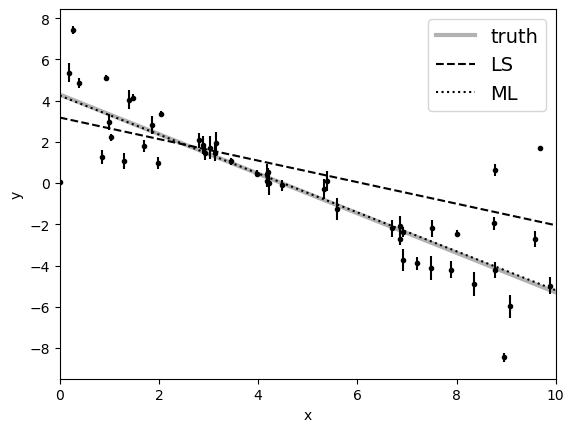

In [11]:
from scipy.optimize import minimize

# Reproducible results
np.random.seed(42)

# Initial guess for the parameters (made imperfect by some Gaussian noise)
initial = np.array([m_true, q_true, np.log(f_true)]) + 0.1 * np.random.randn(3)

# Solve by minimization of -log-likelihood
soln = minimize(lambda *args: -log_likelihood(*args), initial, args=(x, y, yerr))

# Check whether it converged
print("Success status:", soln.success)
print(soln.message)

# Extract maximum likelihood parameter values
m_ml, q_ml, log_f_ml = soln.x
print("Maximum likelihood estimates:")
print(f"m = {m_ml:.4f} (True: {m_true:.4f})")
print(f"q = {q_ml:.4f} (True: {q_true:.4f})")
print(f"f = {np.exp(log_f_ml):.4f} (True: {f_true:.4f})")

# Plot everything we found so far
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + q_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, fitfunc(x0, *fit_pars), "--k", label="LS")
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, q_ml]), ":k", label="ML")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

Much better, but how do we estimate the uncertainties on m and q?


Also, we do not really care much about the value of $f$ but it seems to propagate any uncertainties about its value to the final estimates of $m$ and $q$.

**This is where MCMC comes in.**



## MCMC estimation of model parameters via emcee

We would like to
1. be able to marginalize over "**nuisance parameters**" ($f$ in the example) and to
1. find an estimate of the posterior probability function, i.e., the distribution of parameters that is consistent with the dataset, for the other parameters, i.e., the **model parameters**.

MCMC lets you do both of these things.

### 1. Set up the calculation
Let's write the **posterior probability distribution** in general terms:

$$
p(\boldsymbol{\theta}|\mathbf{d},\mathcal{I}) \propto \pi(\boldsymbol{\theta}) \; \mathcal{L}(\mathbf{d}|\boldsymbol{\theta},\mathcal{I})\,,
$$

where $\pi$ denotes the **prior probability distribution**.  For the case we are examining,

$$
p(m,q,f|\mathbf{x}, \mathbf{y}, \boldsymbol{\sigma}) \propto \pi(m,q,f) \; \mathcal{L}(\mathbf{y}|\{m,q,f\}, \mathbf{x},\boldsymbol{\sigma})\,.
$$

We have already written down and implemented the (log-)likelihood function, so what we are missing is the prior $\pi(m,q,f)$.  This function encodes any previous knowledge that we have about the parameters (e.g., results from other experiments, physically acceptable ranges, etc.).

**The MCMC draws samples from a probability distribution.  We want that distribution to be a probability distribution for the parameters of interest, i.e., $\pi \times \mathcal{L}$.  For each draw, the likelihood will be evaluated and the product of the prior and likelihood yields the posterior (up to a constant, which is the evidence)**.

Let's pick a uniform, "uninformative" prior on $m$, $q$, and $\ln f$:

$$
\pi(m) =
\begin{cases}
1/5.5, & \textrm{if}~m\in (−5, 1/2)\\
0 & \textrm{otherwise}
\end{cases}
$$

$$
\pi(q) =
\begin{cases}
1/10, & \textrm{if}~q\in (0,10)\\
0 & \textrm{otherwise}
\end{cases}
$$

$$
\pi(\ln(f)) =
\begin{cases}
1/11, & \textrm{if}~\ln(f)\in (-10,1)\\
0 & \textrm{otherwise}
\end{cases}
$$

`emcee` **requires the logarithm of the probability density** one wants to sample, so here is the Python log-prior (up to a constant, which we set to 0 with the `return 0.0`):

In [13]:
def log_prior(theta):
    m, q, log_f = theta
    # Return a finite value if theta is in the parameter space region with support for the prior
    if -5.0 < m < 0.5 and 0.0 < q < 10.0 and -0.7 < log_f < 1.0:
        return 0.0
    # Otherwise return -infinity, basically a massive down-weight for the posterior
    return -np.inf

Combining this with the definition of `log_likelihood` we had above, the full log-probability function $\ln p = \ln(\pi\times\mathcal{L}) = \ln\pi + \ln\mathcal{L}$ is:

In [16]:
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    # If theta is outside the support for the prior, return -infinity
    if not np.isfinite(lp):
        return -np.inf
    # Otherwise return the logarithm of prior*likelihood, i.e. log_prior + log_likelihood
    return lp + log_likelihood(theta, x, y, yerr)

### 2. Run the sampler

Now it is straightforward to sample this distribution using `emcee`.

Start by initializing the (32) walkers in a tiny Gaussian ball around the maximum likelihood result: this tends to be a pretty good initialization, in the absence of which you have to provide a starting point.

Then have the walkers perform their (5000) steps of MCMC in parallel and independently from one another.

In [19]:
# The number of walkers
nwalkers = 32

# The dimensionality of the parameter space (m, q, and ln(f) are 3 parameters)
ndim = 3

# The MCMC steps each walker needs to take
nmcmc = 5000

# Initial positions of the 32 walkers: we build this as ML position + noise
pos = soln.x + 1e-4 * np.random.randn(nwalkers, ndim)

# Run the sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
sampler.run_mcmc(pos, nmcmc, progress=True); # The ; avoids some prints to screen

You must install the tqdm library to use progress indicators with emcee


### 3. Look at results

Let's inspect the `sampler` object returned by `emcee`.  It is always a good practice to do this when dealing with new objects one is not familiar with.

In [20]:
dir(sampler)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_moves',
 '_previous_state',
 '_random',
 '_weights',
 'acceptance_fraction',
 'acor',
 'backend',
 'blobs',
 'blobs_dtype',
 'chain',
 'compute_log_prob',
 'flatblobs',
 'flatchain',
 'flatlnprobability',
 'get_autocorr_time',
 'get_blobs',
 'get_chain',
 'get_last_sample',
 'get_log_prob',
 'get_value',
 'iteration',
 'lnprobability',
 'log_prob_fn',
 'ndim',
 'nwalkers',
 'params_are_named',
 'pool',
 'random_state',
 'reset',
 'run_mcmc',
 'sample',
 'vectorize']

In [21]:
print(sampler.__class__)

<class 'emcee.ensemble.EnsembleSampler'>


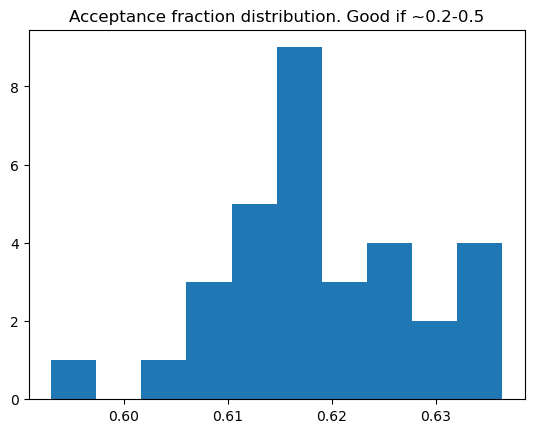

In [33]:
plt.hist(sampler.acceptance_fraction)
# Restituisce la frazione di passi accettati nel metodo Metropolis-Hastings
# 1) Ad ogni step si propone un nuovo set di parametri
# 2) Si confronta la probabilità posteriore del nuovo vs vecchio stato
# 3) Se la probabilità è migliore (o abbastanza buona per caso), il passo è accettato e il walker si muove
# 4) Se no, il passo è rifiutato e il walker rimane dov'era
plt.title("Acceptance fraction distribution. Good if ~0.2-0.5");
# dir(sampler.acceptance_fraction)

Ideally the plot above is somewhat regular: a posteriori, we can try running with `ndim=320` for example.

To see what the sampler did, a good first step is to look at the time series of the parameters in the chain.  The samples can be accessed using the `EnsembleSampler.get_chain()` method.  This returns an array with the shape `(nmcmc, nwalkers, ndim)`, providing the parameter values for each walker at each step in the chain.

We will overlay all the chains.  If one wishes to plot a specific chain, say the first one, `samples[:, 0, i]` should be used in the code below, rather than `samples[:, :, i]`.

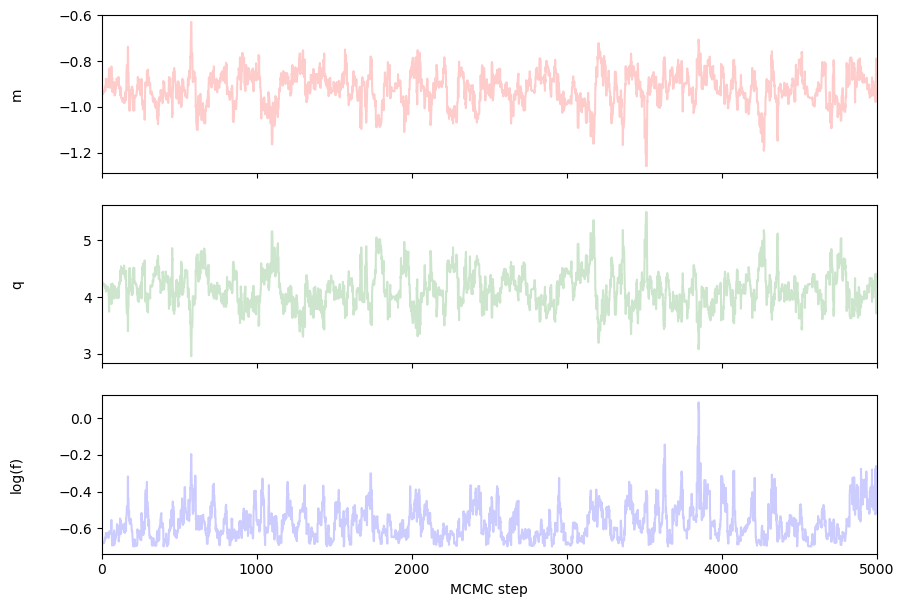

In [25]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["m", "q", "log(f)"]
col = ['r', 'g', 'b']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, 0, i], col[i], alpha=0.2)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("MCMC step"); # The ; avoids an unwanted output to screen.

The walkers start in small distributions around the maximum (log-)likelihood values and then wander and start exploring the full posterior distribution.

After fewer than 50 steps, the samples seem pretty well “burnt-in.”  It is hard to define this statement quantitatively, but an estimate of the integrated autocorrelation time [number of steps, really]

In [27]:
tau = sampler.get_autocorr_time()
print(tau)

[40.55400391 39.79711472 45.38716091]


suggests that $\sim 40$ steps are needed for the chain to “forget” where it started.  It is reasonable to throw away a few times this number of steps as “burn-in."

Let’s discard the initial 100 steps of each walker, *thin* (i.e., take strides) by about half the autocorrelation time (20 steps) for each walker, and flatten the chains so that we have a flat list of samples:

In [28]:
flat_samples = sampler.get_chain(discard=100, thin=20, flat=True)
print(flat_samples.shape)

(7840, 3)


Quick check of the number returned, according to the logic above:

In [34]:
assert len(flat_samples) == int(nwalkers*(nmcmc - 100)/20)

Now let’s make a [**corner plot**](https://corner.readthedocs.io/en/latest/), one of the most useful plots related to Bayesian sampling calculations.  In this case we know and will overlay the "truth" (while in realistic scenarios this is not possible).

<Figure size 1000x800 with 0 Axes>

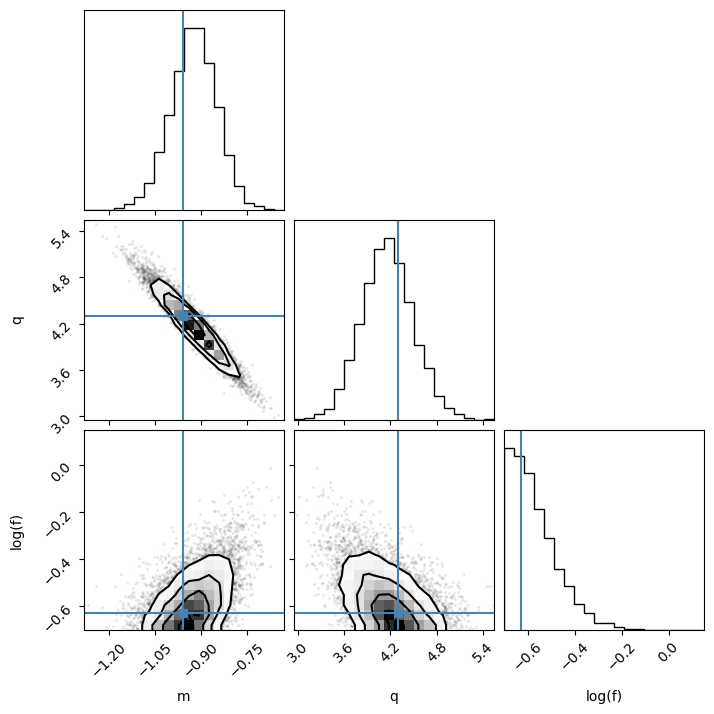

In [40]:
import corner
plt.figure(figsize=(10, 8))
fig = corner.corner(flat_samples, labels=labels, truths=[m_true, q_true, np.log(f_true)])

These are **all the one and two dimensional projections of the posterior probability distributions** of the parameters we are inferring.  This allows you to quickly visualize all of the covariances between parameters.

To find the marginalized distribution for a parameter or set of parameters using the results of the MCMC chain, one projects the samples into the sub-space of interest and then makes a histogram over it.  Corner plots are doing this in all possibile 2D and 1D sub-spaces.  They are numerically evaluating and displaying

$$
p(\theta_1|\mathbf{d}, \mathcal{I}) = \int p(\theta_1, \theta_2, \ldots, \theta_N|\mathbf{d}, \mathcal{I}) d\theta_2 d\theta_3 \ldots d\theta_N
$$

on the diagonals, and

$$
p(\theta_1, \theta_2|\mathbf{d}, \mathcal{I}) = \int p(\theta_1, \theta_2, \ldots, \theta_N|\mathbf{d}, \mathcal{I}) d\theta_3 d\theta_4 \ldots d\theta_N\,.
$$

off the diagonals.

Another diagnostic plot is the projection of the results into the space of the observed data. Choose a few (say 100 in this case) samples from the chain and plot them on top of the data points.

In doing so, for syntax brevity, we use the dot product (`np.cdot`) and generate a Vandermonde matrix (with the `np.vander` method) to quickly produce $m x_0+q$ for each element in $x_0$. The $i$-th column of the Vandermonde matrix is the $N-i-1$ power of the input vector, where $N$ is an argument of the method (by default the length of the input vector): row $i$ of `np.vander(a, 2)` has elements `a[i]` and 1.  Therefore `np.dot(np.vander(x0, 2), [a, b])` represents $a\vec{x}_0 + \vec{b}$, where $\vec{b}$ is a vector with the same rank of $\vec{x}_0$.

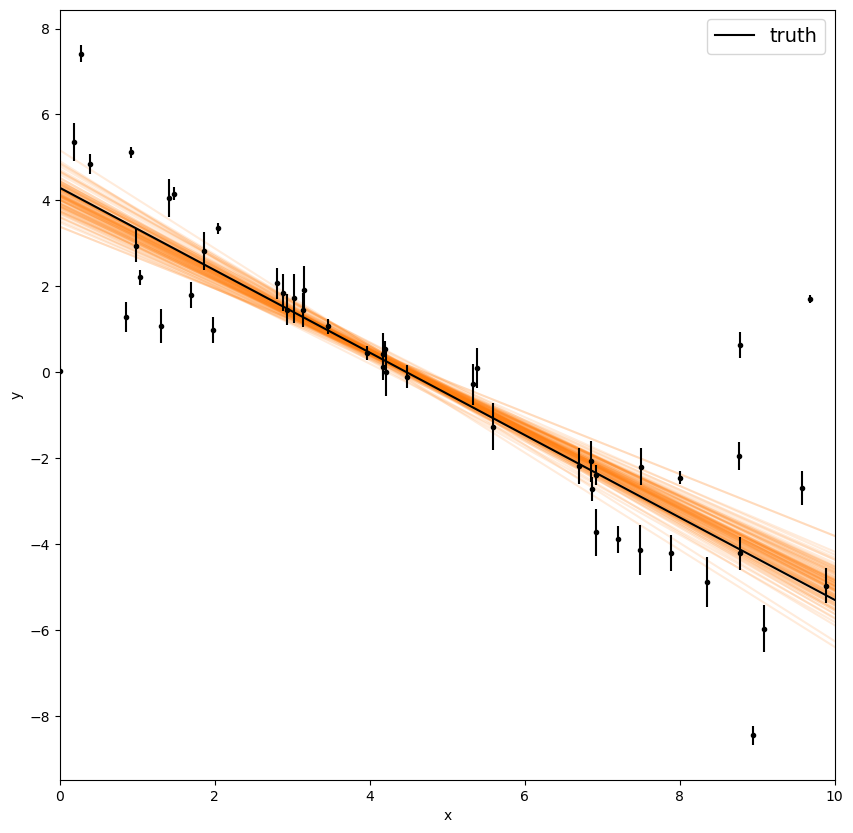

In [41]:
fig = plt.figure(figsize=(10,10))

inds = np.random.randint(len(flat_samples), size=100)
for ind in inds:
    sample = flat_samples[ind]
    # Fancy way of doing m*x0+q for all x0 values, given m and q from the sample:
    # take the dot product between all (x0,1) pairs and one (m,q) at a time
    plt.plot(x0, np.dot(np.vander(x0, 2), sample[:2]), "C1", alpha=0.15)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)

plt.plot(x0, m_true * x0 + q_true, "k", label="truth")

plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

Last but not least, we inspect the parameter values and their **credible intervals**.

Say you decide to quote the 90% credible intervals, with the median value.  You need the 5th, 50th, and 95th percentile of the samples in the marginalized distributions.

In [47]:
from IPython.display import display, Math

msg = r"\mathrm{MCMC~results:}"
display(Math(msg))
txt = r"\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
for i in range(ndim):
    ptile = np.percentile(flat_samples[:, i], [5, 50, 95])
    interval = np.diff(ptile)
    display(Math(txt.format(ptile[1], interval[0], interval[1], labels[i])))

print("\n")
msg = r"\mathrm{As~a~reminder,~the~true~values~were:}"
display(Math(msg))
txt = r"\mathrm{{{0}}} = {1:.4f}"
vals = [m_true, q_true, np.log(f_true)]
for i in range(len(vals)):
    display(Math(txt.format(labels[i], vals[i])))

print("\n")
msg = r"\mathrm{As~a~reminder,~the~maximum~likelihood~estimates~were:}"
display(Math(msg))
txt = r"\mathrm{{{0}}} = {1:.4f}"
vals = [m_ml, q_ml, log_f_ml]
for i in range(len(vals)):
    display(Math(txt.format(labels[i], vals[i])))

print("\n")   
msg = r"\mathrm{As~a~reminder,~the~least-squares~values~were:}"
display(Math(msg))
txt = r"\mathrm{{{0}}} = {1: .4f} \pm {2: .4f}"
for i in range(len(fit_pars)):
    display(Math(txt.format(labels[i], fit_pars[i], cov_matrix[i, i]**0.5)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<div class="alert alert-info">
To acquire some feel for Bayesian inference results, you should try the following.
    
1. Limit the prior so that it does not cover the true value of one of the parameters: what do the chains/posterior for the nuissance parameter look like?  Two typical pathological behaviours may be obtained when setting the lower end of the support for `log_f` to -0.6 and -0.7.
1. Do not include additional displacements in the mock data: what do the chains/posterior for the nuissance parameter look like?
1. Keep the additional displacements in the mock data and remove the nuissance parameter from the model used to interpret the data: what do the chains/posterior for the nuissance parameter look like?
1. Increase the complexity of the inference model: try a generic quadratic fucntion or a cubic one and see the results for the extra parameters.
1. Use a completely wrong inference model, e.g., a sinusoidal.
1. And of course, try to generate mock data with a completely different "true" model and change the inference model as well.

</div>